## About Yulu



Yulu is India’s leading micro-mobility service provider, which offers unique vehicles for the daily commute. Starting off as a mission to eliminate traffic congestion in India, Yulu provides the safest commute solution through a user-friendly mobile app to enable shared, solo and sustainable commuting.

Yulu zones are located at all the appropriate locations (including metro stations, bus stands, office spaces, residential areas, corporate offices, etc) to make those first and last miles smooth, affordable, and convenient!

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.

## Problem Statement

The company wants to know:

Q1- Which variables are significant in predicting the demand for shared electric cycles in the Indian market?


Q2- How well those variables describe the electric cycle demands


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import shapiro

In [19]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("bike_sharing.csv")

Saving bike_sharing.csv to bike_sharing (1).csv


In [20]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [21]:
df.shape

(10886, 12)

## Insights
1- There are 10886 rows and 12 columns

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [23]:
df.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [24]:
df.duplicated().sum()

np.int64(0)

## Insights
1- There are no null values in the datasets nor any duplicated values

In [25]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


## Insights
1- In the above table we can see that in "windspeed" column the mid value is 12.9 and highest is 57 , so there are outliers present in the column

2- Even in the columns such as casual , registered and count have very high values ,we can safely assume that there are outliers but its mostly the demand of the bicycle on that day ,so we dont need to remove the outliers



In [26]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['datetime'].dt.year.value_counts()

,count
datetime,
2012,5464
2011,5422


##Insights

1- I converted datetime column from object to datetime data type to see how many people bought or rented cycle in each year

## Uni-variate Graphs for Numerical Columns

<Axes: xlabel='count', ylabel='Count'>

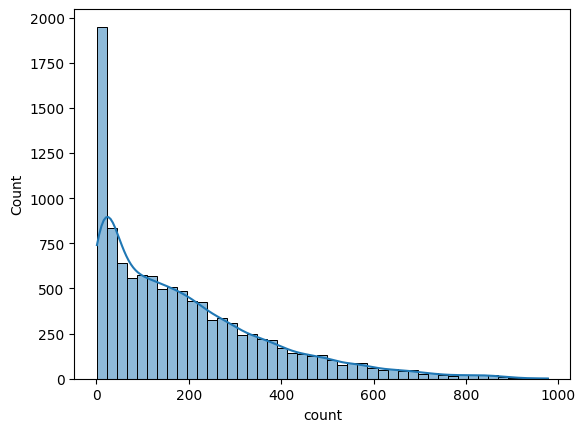

In [27]:
sns.histplot(df["count"], kde = True)

<Axes: xlabel='temp', ylabel='Count'>

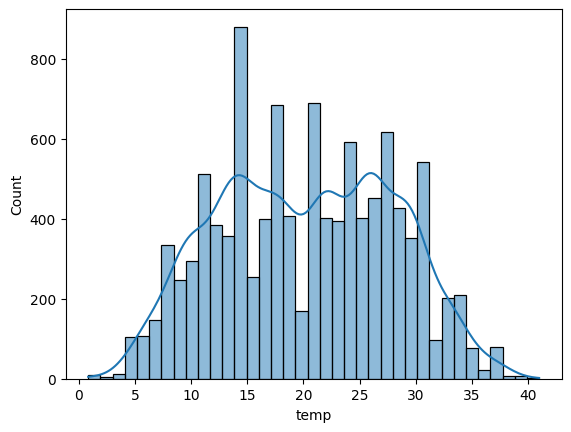

In [28]:
sns.histplot(df["temp"],kde = True)

<Axes: xlabel='humidity', ylabel='Count'>

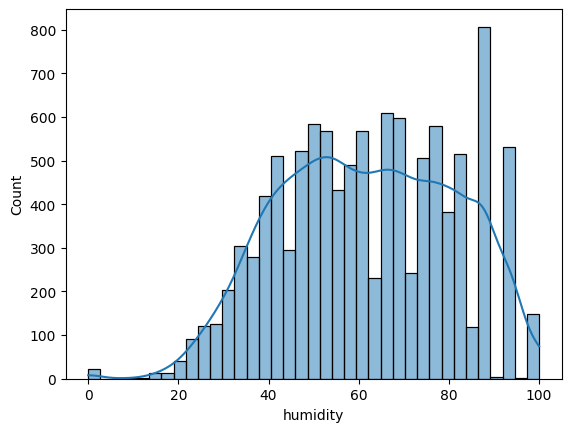

In [29]:
sns.histplot(df["humidity"],kde = True)

## Univariate Graphs for Categorical Columns

seasons

1: spring

 2: summer

  3: fall
  
   4: winter

[Text(0, 0, '2686'),
 Text(0, 0, '2733'),
 Text(0, 0, '2733'),
 Text(0, 0, '2734')]

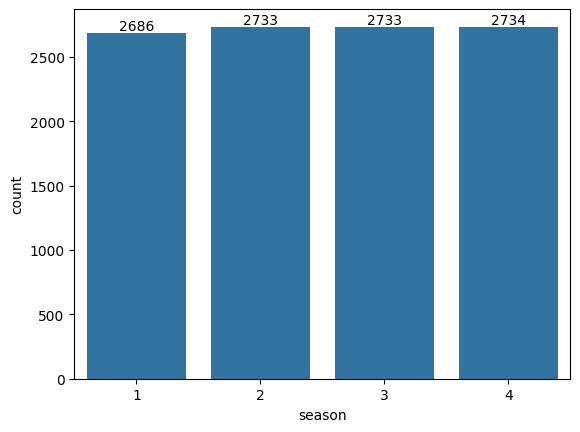

In [30]:
ax = sns.countplot(x = "season", data = df)
ax.bar_label(ax.containers[0])

## Insights
1- From the above graph we can see that winter season is the most popular season where most people either rent or buy yulu bicycle followed by fall , summer and spring



weather:


 1: Clear, Few clouds, partly cloudy


 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist


 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds


 4: Heavy Rain + Ice Pellets + Thunderstorm + Mist, Snow + Fog


[Text(0, 0, '7192'), Text(0, 0, '2834'), Text(0, 0, '859'), Text(0, 0, '1')]

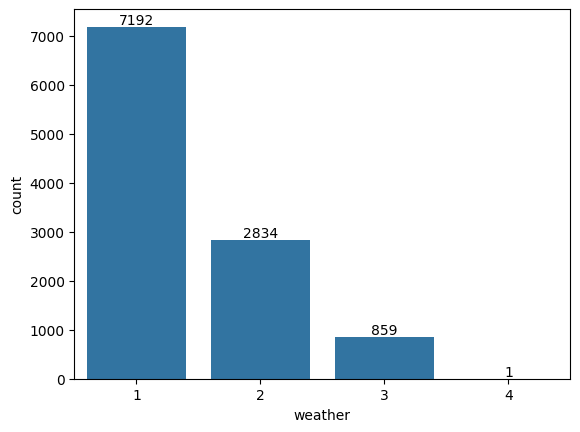

In [31]:
ax = sns.countplot(x = "weather", data = df)
ax.bar_label(ax.containers[0])

## Insights
1- From the above graph we can see that most amount of rented/registered bicycles is when weather is Clear, have Few clouds or partly cloudy

<Axes: xlabel='count'>

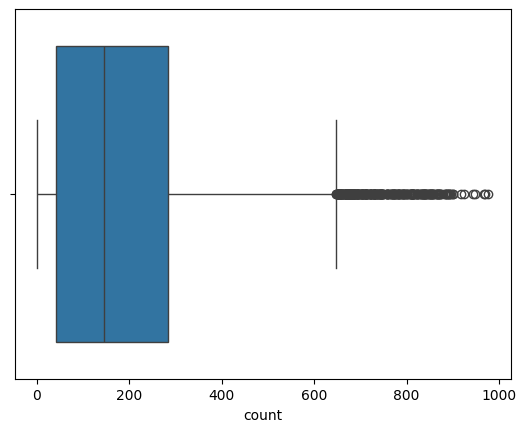

In [32]:
sns.boxplot(x = df['count'])

/tmp/ipykernel_23394/708827336.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['count']),bins=10)


<Axes: xlabel='count', ylabel='Density'>

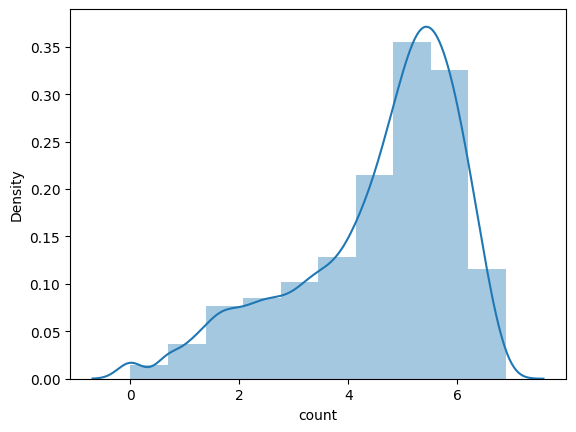

In [33]:
sns.distplot(np.log(df['count']),bins=10)

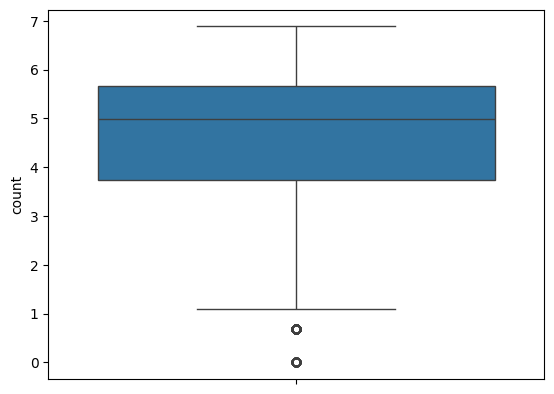

In [75]:
sns.boxplot(y=np.log(df['count']))
plt.show()

<Axes: xlabel='humidity'>

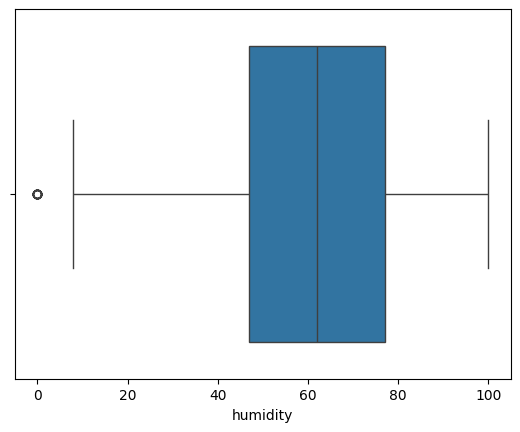

In [34]:
sns.boxplot(x = df['humidity'])

<Axes: xlabel='windspeed'>

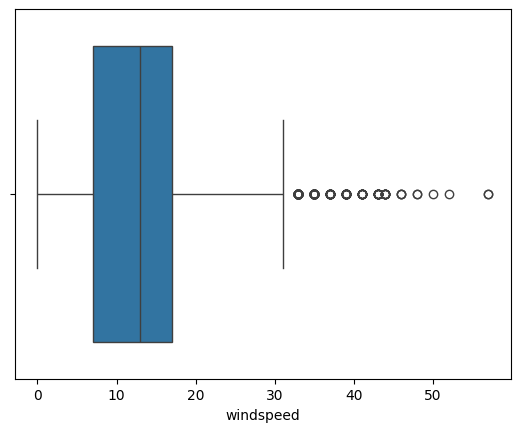

In [35]:
sns.boxplot(x = df['windspeed'])

<Axes: xlabel='temp'>

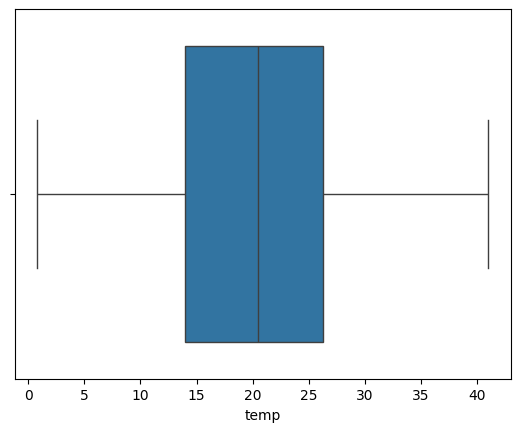

In [38]:
sns.boxplot(x = df['temp'])

<Axes: xlabel='atemp'>

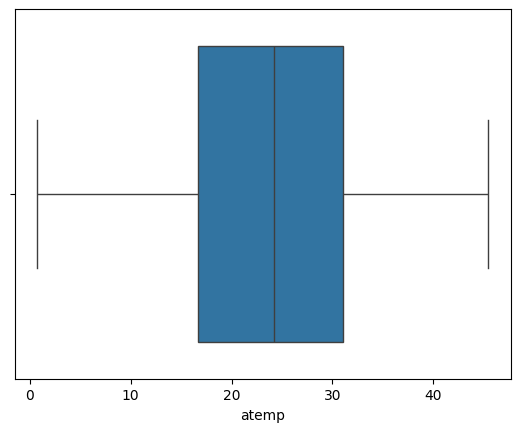

In [39]:
sns.boxplot(x = df['atemp'])

##Insights

1- I used Bocplot on numerical columns to see which columns have outliers and which dont

2- So in the above boxplots- only windspeed and count columns have most outliers

3- I capped the outliers in count using log function and left windspeed column.

4- So i foucused on cleaning the Outliers from windspeed column using IQR method


## Correlation


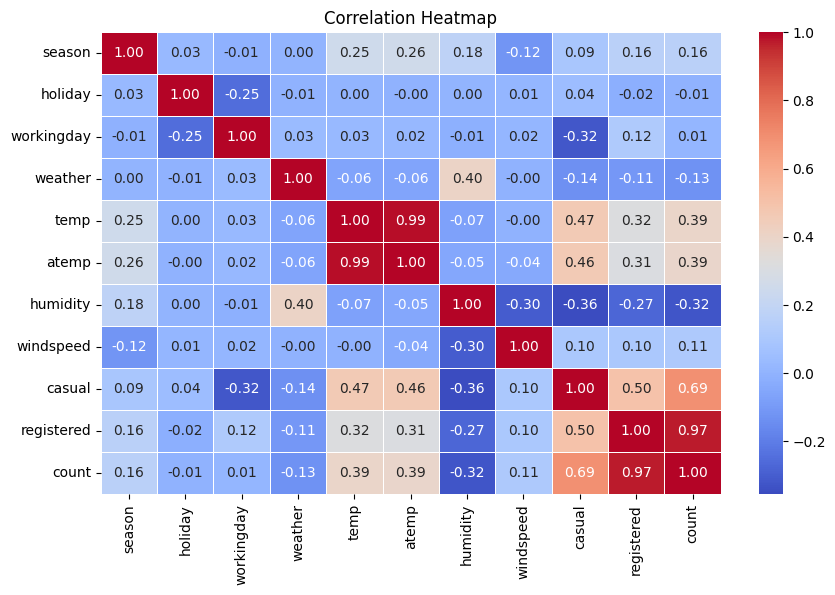

In [40]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

#Insights

1- In the heatmap, we can see which columns are correlated with which columns , as you can see registered and count has a correlation of 0.97 and we know that in count column registration's count is also included which can create redundant data and less accurate data

2- Same with atemp and temp column as both the columns are relatively same so we can remove one of the column

In [41]:
df.drop(columns=['atemp'], inplace=True)

In [42]:
df.drop(columns=['casual', 'registered'], inplace=True)

In [43]:
df.head()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,81,0.0,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,80,0.0,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,80,0.0,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,75,0.0,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,75,0.0,1


##Hypothesis Testing


## Problem 1 - To check if there are any significant difference between the no. of bike rides on Weekdays and Weekends?

In [44]:
a = df[df['workingday']== 1]['count']
b = df[df['workingday']== 0]['count']
print(a,b)

47         5
48         2
49         1
50         3
51        30
        ... 
10881    336
10882    241
10883    168
10884    129
10885     88
Name: count, Length: 7255, dtype: int64 0         16
1         40
2         32
3         13
4          1
        ... 
10809    109
10810    122
10811    106
10812     89
10813     33
Name: count, Length: 3404, dtype: int64


In [45]:
stat, p_value = shapiro(a)

print(f"Statistic: {stat}, P-Value: {p_value}")

Statistic: 0.870177995846552, P-Value: 5.907975824815297e-61


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7255.
  res = hypotest_fun_out(*samples, **kwds)


In [46]:
alpha = 0.05

if p_value > alpha:
    print("The data is normally distributed (fail to reject H0)")
else:
    print("The data is not normally distributed (reject H0)")

The data is not normally distributed (reject H0)


In [47]:
stat, p_value = shapiro(b)

print(f"Statistic: {stat}, P-Value: {p_value}")

Statistic: 0.8860197786442658, P-Value: 1.2913252248156533e-44


In [48]:
alpha = 0.05

if p_value > alpha:
    print("The data is normally distributed (fail to reject H0)")
else:
    print("The data is not normally distributed (reject H0)")

The data is not normally distributed (reject H0)


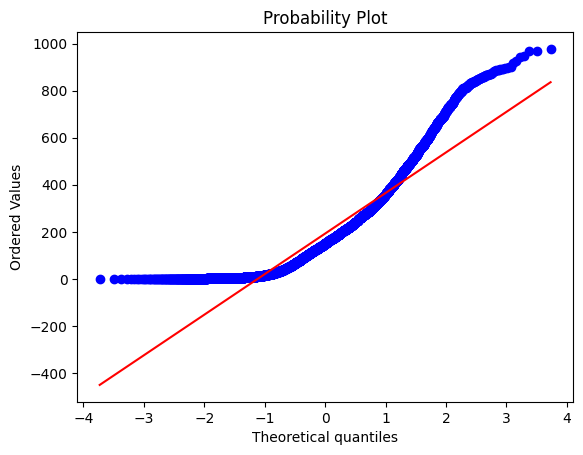

In [49]:
from scipy import stats


# Perform the probability plot
stats.probplot(a, dist="norm", plot=plt)

plt.show()

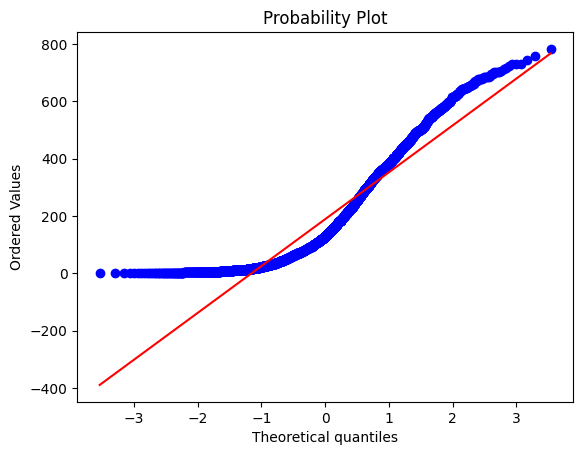

In [50]:
stats.probplot(b, dist="norm", plot=plt)

plt.show()

##Insights

1- Before doing any Tests i used assumptions tests to see the normality of the data , i used shapiro's test and QQ plot

In [51]:
t_stat, p_val = ttest_ind(a, b, alternative="less")

print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_val}")

T-Statistic: 1.1025489812826474
P-Value: 0.8648760129570039


In [52]:
alpha = 0.05

if p_val < alpha:
  print("Reject H0")

else:
  print("Fail to reject H0")

Fail to reject H0


## Insights

1- The objective was to determine any significant difference between the no. of bike rides on Weekdays and Weekends

2 H0:  The demand of bikes on weekdays is greater or similar to the demand of bikes on weekend.

  Ha:  The demand of bikes on weekdays is less than the demand of bikes on weekend.



3- The hypothesis test used here was 2 sample T test and p_value was greater than 0.05 which means we failed to reject our original hypothesis which means bikes on weekdays is less than the demand of bikes on weekend

4- Some assumptions such as normality/equality of variance showed deviations; however, analysis was continued with careful interpretation.

## Recommendations
1- Focus on giving offers and discounts during low-demand days

2- Maintain your business model as how it is

3- Need future analysis with additiional variables

4- No statistical evidence was found

## Problem 2-  To check if the demand of bicycles on rent is the same for different Weather conditions

weather:

o 1: Clear, Few clouds, partly cloudy


o 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist


o 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds


o 4: Heavy Rain + Ice Pellets + Thunderstorm + Mist, Snow + Fog


In [53]:
x = df[df['weather'] == 1]['count']
y = df[df['weather'] == 2]['count']
z = df[df['weather'] == 3]['count']
w = df[df['weather'] == 4]['count']

## Assumption Tests - Shapiro's Test

In [54]:
stat, p_value = shapiro(x)

print(f"Statistic: {stat}, P-Value: {p_value}")

Statistic: 0.8912536874175029, P-Value: 4.725227836136959e-57


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7039.
  res = hypotest_fun_out(*samples, **kwds)


In [55]:
alpha = 0.05

if p_value > alpha:
    print("The data is normally distributed (fail to reject H0)")
else:
    print("The data is not normally distributed (reject H0)")

The data is not normally distributed (reject H0)


In [56]:
stat, p_value = shapiro(y)

print(f"Statistic: {stat}, P-Value: {p_value}")

Statistic: 0.8769384007798086, P-Value: 1.746669019343988e-42


In [57]:
alpha = 0.05

if p_value > alpha:
    print("The data is normally distributed (fail to reject H0)")
else:
    print("The data is not normally distributed (reject H0)")

The data is not normally distributed (reject H0)


In [58]:
stat, p_value = shapiro(z)

print(f"Statistic: {stat}, P-Value: {p_value}")

Statistic: 0.7663271257125236, P-Value: 1.3144175351029663e-32


In [59]:
alpha = 0.05

if p_value > alpha:
    print("The data is normally distributed (fail to reject H0)")
else:
    print("The data is not normally distributed (reject H0)")

The data is not normally distributed (reject H0)


In [60]:
from scipy.stats import levene
stat, p_value = levene(x,y,z,w)
stat,p_value

(np.float64(56.75951331702621), np.float64(2.1550859059949926e-36))

In [61]:
alpha = 0.05

if p_value > alpha:
    print("Variance are equal")
else:
    print("variance are not equal")

variance are not equal


## KW Test

In [78]:
from scipy.stats import kruskal
stat,p_value=kruskal(x,y,z,w)
stat,p_value

(np.float64(200.50919493728026), np.float64(3.274452726500978e-43))

In [79]:
alpha = 0.05

if p_value < alpha:
  print("Reject H0")

else:
  print("Fail to reject H0")

Reject H0


# Insights

1- The objective was to determine to check if the demand of bicycles on rent is the same for different Weather conditions

2- First i used an Assumptions test- Shapiro's test to see the normality and also used levenes test to check for variance, both of them failed so i cant use one way annova so i used a non parametric test called KW test

3-H0:  The average no. of bike rides in different weather conditions are equal.

4-Ha:  The average no. of bike rides in different weather conditions are not equal.


5- The result we got from the hypothesis test is that demand for bicycle rentals is the same across different weather conditions



## Recommendations
1- Since no significant demand was found , the comapany can focus on additioanl factors like seasonality , holidays , user-behaviour and time based

## Problem 3- To check if the demand of bicycles on rent is the same for different Seasons?

In [64]:
s1 = df[df['season'] == 1]['count']
s2 = df[df['season'] == 2]['count']
s3 = df[df['season'] == 3]['count']
s4 = df[df['season'] == 4]['count']


<Axes: xlabel='count', ylabel='Count'>

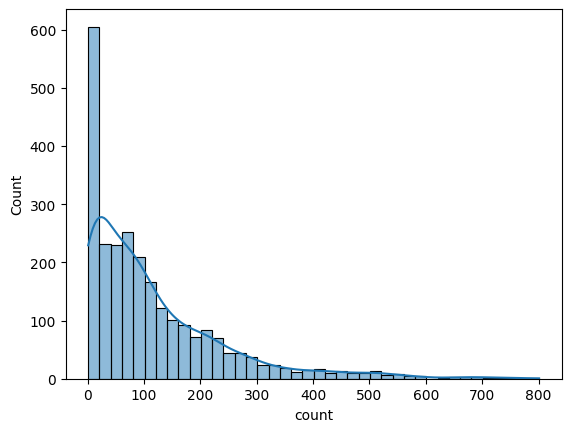

In [65]:
sns.histplot(s1, kde = True)

<Axes: xlabel='count', ylabel='Count'>

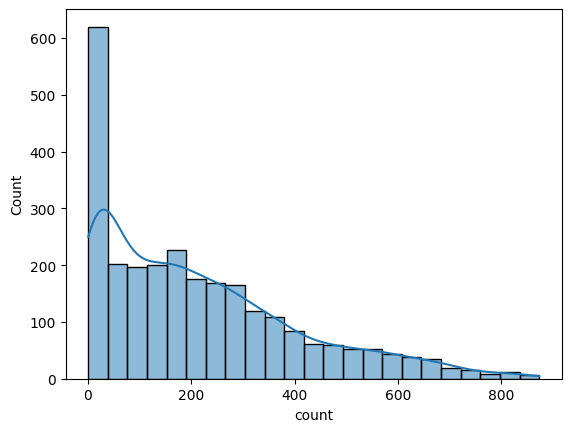

In [66]:
sns.histplot(s2, kde = True)

<Axes: xlabel='count', ylabel='Count'>

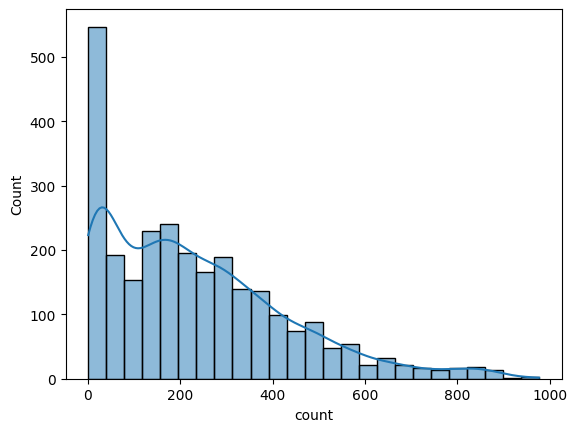

In [67]:
sns.histplot(s3, kde = True)

<Axes: xlabel='count', ylabel='Count'>

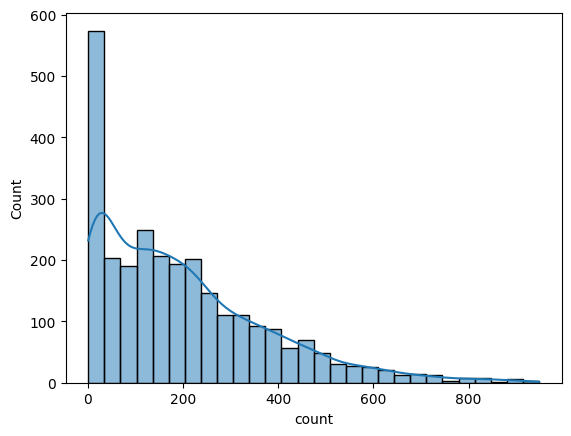

In [68]:
sns.histplot(s4, kde = True)

In [80]:
stat,p_value=kruskal(x,y,z,w)


print("Test Statistic:", stat)
print("P-value:", p_value)



Test Statistic: 200.50919493728026
P-value: 3.274452726500978e-43


In [81]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


## Insights

1- The objective is to determine if the demand of bicycles on rent is the same for different Seasons

2- Null Hypothesis (H₀): The demand for bicycle rentals is the same across different seasons.  

3- Alternative Hypothesis (H₁): The demand for bicycle rentals is not the same across different seasons.

4- The test we used here one way ANNOVA and the p_value was less than 0.05 which means demand for bicycle rentals is the same across seasons


## Recommendations

1- Maintain your business model as how it is

2- Need future analysis with additiional variables

3- No statistical evidence was found


## Problem 4- To check if the Weather conditions are significantly different during different Seasons?

## Weather

 1: Clear, Few clouds, partly cloudy

 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist

 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds

 4: Heavy Rain + Ice Pellets + Thunderstorm + Mist, Snow + Fog



 ## Season
 1: spring

 2: summer

 3: fall

 4: winter


In [71]:
sw = pd.crosstab(df['season'], df['weather'])
sw

weather,1,2,3,4
season,,,,
1,1662,699,204,1
2,1764,696,214,0
3,1921,599,188,0
4,1692,801,218,0


In [72]:
stat, p_value, dof, expected = chi2_contingency(sw)
print("Chi-Square Statistic:", stat)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 51.81303239370452
P-value: 4.903604163954192e-08
Degrees of Freedom: 9


In [73]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


## Insights

1-H0:  Weather conditions are independent of the season.

2-Ha:  Weather condition depends on the ongoing season.

3- As we can see p value is less than the alpha so we will reject null hypothesis which means weather conditions depends on the ongoing season